In [35]:
import numpy as np 
import matplotlib.pyplot as plt
from sympy import symbols, expand, Poly,lambdify,diff
from scipy.interpolate import lagrange
from scipy.interpolate import CubicSpline
import math
from scipy.optimize import curve_fit
from numpy.polynomial import Polynomial

# Zadanie 1


Wzór interpolacyjny Lagrange'a dla funkcji kwadratowej, przechodzącej przez punkty $(h_0, \rho_0)$, $(h_1, \rho_1)$, $(h_2, \rho_2)$, można zapisać jako:


$P(h) = \rho_0 \cdot L_0(h) + \rho_1 \cdot L_1(h) + \rho_2 \cdot L_2(h)$


gdzie:


$L_0(h) = \frac{(h - h_1)(h - h_2)}{(h_0 - h_1)(h_0 - h_2)}$



$L_1(h) = \frac{(h - h_0)(h - h_2)}{(h_1 - h_0)(h_1 - h_2)}$



$L_2(h) = \frac{(h - h_0)(h - h_1)}{(h_2 - h_0)(h_2 - h_1)}$


In [2]:
def lagrange_interpolation(x_points, y_points):
    """
    Interpolacja Lagrange'a - wyznaczenie funkcji kwadratowej.
    :param x_points: lista wartości x (punkty węzłowe)
    :param y_points: lista wartości y odpowiadających punktom węzłowym
    :return: współczynniki wielomianu kwadratowego
    """
    x = symbols('h')
    n = len(x_points)
    result = 0

    for i in range(n):
        # Obliczamy wartość L_i(x) i dodajemy do wyniku
        Li = y_points[i]
        for j in range(n):
            if i != j:
                Li *= (x - x_points[j]) / (x_points[i] - x_points[j])
        result += Li

    return expand(result)

# Dane wejściowe z zadania
h_values = [0, 3, 6]  # wysokości w km
rho_values = [1.225, 0.905, 0.652]  # gęstości powietrza w kg/m^3

# Wyznaczamy współczynniki funkcji kwadratowej interpolacyjnej ρ(h)
coefficients = lagrange_interpolation(h_values, rho_values)

print(f"Funkcja gęstości powietrza ρ(h): {coefficients}")


Funkcja gęstości powietrza ρ(h): 0.00372222222222223*h**2 - 0.117833333333333*h + 1.225


Dla porównnania za pomocą funkcji bibliotecznych

In [3]:
# Wyznaczanie wielomianu przy użyciu scipy.interpolate.lagrange
polynomial = lagrange(h_values, rho_values)

# Współczynniki wielomianu
coefficients_library = np.poly1d(polynomial).coefficients

print("\nWspółczynniki funkcji kwadratowej uzyskane przy użyciu biblioteki scipy:")
print(coefficients_library)


Współczynniki funkcji kwadratowej uzyskane przy użyciu biblioteki scipy:
[ 0.00372222 -0.11783333  1.225     ]


# Zadanie 2

In [4]:
# Dane wejściowe do interpolacji funkcjami sklejanymi
Re_values = [0.2, 2, 20, 200, 2000, 20000]
cD_values = [103, 13.9, 2.72, 0.8, 0.401, 0.433]

# Tworzenie funkcji interpolacyjnej przy użyciu naturalnych funkcji sklejanych
cs = CubicSpline(Re_values, cD_values, bc_type='natural')

# Obliczanie cD dla podanych wartości Re
Re_test_values = [5, 50, 5000]
cD_test_values = cs(Re_test_values)

# Wyświetlanie wyników
print("Wartości współczynnika oporu cD dla podanych wartości Re przy użyciu interpolacji funkcjami sklejanymi:")
for Re, cD in zip(Re_test_values, cD_test_values):
    print(f"Re = {Re}: cD = {cD:.6f}")

Wartości współczynnika oporu cD dla podanych wartości Re przy użyciu interpolacji funkcjami sklejanymi:
Re = 5: cD = -88.940210
Re = 50: cD = 458.288421
Re = 5000: cD = 9920.955712


# Zadanie 3

Za pomocą interpolacji wielomianowej Lagragne'a daje nam inne wyniki

In [16]:
# Dane wejściowe
x_points = [0.2, 2, 20, 200, 2000, 20000]
y_points = [103, 13.9, 2.72, 0.8, 0.401, 0.433]

# Wyznaczenie wielomianu interpolacyjnego
polynomial = lagrange_interpolation(x_points, y_points)
print(f"Wielomian interpolacyjny: {polynomial}")

# Obliczenie wartości cD dla Re = 5, 50, 5000
re_values = [5, 50, 5000]
cd_values = [polynomial.subs('h', re) for re in re_values]

for re, cd in zip(re_values, cd_values):
    print(f"cD dla Re = {re}: {cd}")

Wielomian interpolacyjny: -3.08493537203026e-10*h**5 + 6.85542039971305e-6*h**4 - 0.0138495051938276*h**3 + 2.77301829210174*h**2 - 55.5392093650555*h + 113.9970319264
cD dla Re = 5: -96.1004620718548
cD dla Re = 50: 2581.14411796735
cD dla Re = 5000: 1658455172.08550


Metoda interpolacji wielomianowej, jak Lagrange'a, często daje gorsze wyniki, ponieważ używa jednego wielomianu wysokiego stopnia do aproksymacji wszystkich punktów, co prowadzi do niestabilności numerycznej i dużych oscylacji (efekt Rungego). Wielomiany wysokiego stopnia mają tendencję do dawania dużych błędów, szczególnie na krańcach przedziału. Z kolei funkcje sklejane używają lokalnych wielomianów niskiego stopnia, co pozwala lepiej dopasować się do lokalnych zmian w danych i uniknąć dużych oscylacji. W efekcie interpolacja funkcjami sklejanymi jest bardziej stabilna i daje bardziej precyzyjne wyniki.

# Zadanie 4

Chcemy dopasować prostą do danych $(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)$ tak, aby minimalizować błąd:

$
S(A, B) = \sum_{i=1}^n (y_i - (A + B x_i))^2
$

Gdzie nasze $A=ln(a)$ i $B=b$

Aby znaleźć wartości $ A $ i $ B $ które minimalizują sumę kwadratów reszt (błędy), obliczamy pochodne cząstkowe funkcji błędu $ S $ względem $ A $ i $ B $, a następnie przyrównujemy je do zera.

1. **Pochodna względem \( A \)**:

$
\frac{\partial S}{\partial A} = -2 \sum_{i=1}^n (y_i - A - B x_i) = 0
$

2. **Pochodna względem \( B \)**:

$
\frac{\partial S}{\partial B} = -2 \sum_{i=1}^n (y_i - A - B x_i) x_i = 0
$

Po uproszczeniu tych równań otrzymujemy układ równań normalnych:

$
\sum_{i=1}^n y_i = nA + B \sum_{i=1}^n x_i
$

$
\sum_{i=1}^n x_i y_i = A \sum_{i=1}^n x_i + B \sum_{i=1}^n x_i^2
$

Po przekształceniu otrzymujemy wzory:

$
B = \frac{n \sum_{i=1}^n x_i y_i - \sum_{i=1}^n x_i \sum_{i=1}^n y_i}{n \sum_{i=1}^n x_i^2 - \left( \sum_{i=1}^n x_i \right)^2}
$

$
A = \frac{1}{n} \sum_{i=1}^n y_i - B \cdot \frac{1}{n} \sum_{i=1}^n x_i
$



Wyznaczone parametry (ręczna aproksymacja): a = 3.7889, b = 0.5366
Odchylenie standardowe (ręczna aproksymacja): 1.7140
Równanie aproksymującej funkcji (ręczna aproksymacja): f(x) = 3.7889 * e^(0.5366 * x)


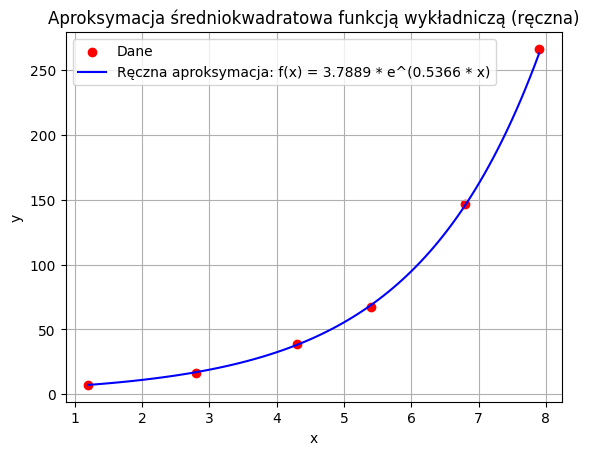

In [32]:


# Definiujemy dane
x_data = np.array([1.2, 2.8, 4.3, 5.4, 6.8, 7.9])
y_data = np.array([7.5, 16.1, 38.9, 67.0, 146.6, 266.2])

# Przekształcamy dane do postaci liniowej
# f(x) = a * e^(b * x) -> ln(f(x)) = ln(a) + b * x
x = x_data
y = np.log(y_data)

# Liczba punktów
data_len = len(x)

# Obliczanie współczynników A i B (gdzie A = ln(a) i B = b)
S_x = np.sum(x)
S_y = np.sum(y)
S_xx = np.sum(x**2)
S_xy = np.sum(x * y)

# Wzory na współczynniki prostej regresji
B = (data_len * S_xy - S_x * S_y) / (data_len * S_xx - S_x**2)
A = (S_y - B * S_x) / data_len

# Przekształcenie do parametrów a i b
a = np.exp(A)
b = B

# Definiujemy aproksymowaną funkcję f(x) = a * e^(b * x)
def approximating_function(x):
    return a * np.exp(b * x)

# Obliczamy wartości aproksymowane
y_approx = approximating_function(x_data)

# Obliczamy odchylenie standardowe
residuals = y_data - y_approx
standard_deviation = np.sqrt(np.sum(residuals**2) / len(x_data))

# Wyświetlenie wyników
equation_str = f"f(x) = {a:.4f} * e^({b:.4f} * x)"
print(f"Wyznaczone parametry (ręczna aproksymacja): a = {a:.4f}, b = {b:.4f}")
print(f"Odchylenie standardowe (ręczna aproksymacja): {standard_deviation:.4f}")
print(f"Równanie aproksymującej funkcji (ręczna aproksymacja): {equation_str}")

# Rysowanie wykresu (ręczna aproksymacja)
def plot_approximation_manual():
    plt.scatter(x_data, y_data, color='red', label='Dane')
    x_plot = np.linspace(min(x_data), max(x_data), 100)
    y_plot = approximating_function(x_plot)
    plt.plot(x_plot, y_plot, color='blue', label=f'Ręczna aproksymacja: {equation_str}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Aproksymacja średniokwadratowa funkcją wykładniczą (ręczna)')
    plt.grid()
    plt.show()

plot_approximation_manual()

Za pomocą funkcji wbudowanej

Wyznaczone parametry (wbudowana aproksymacja): a = 3.6137, b = 0.5442
Odchylenie standardowe (wbudowana aproksymacja): 0.8347
Równanie aproksymującej funkcji (wbudowana aproksymacja): f(x) = 3.6137 * e^(0.5442 * x)


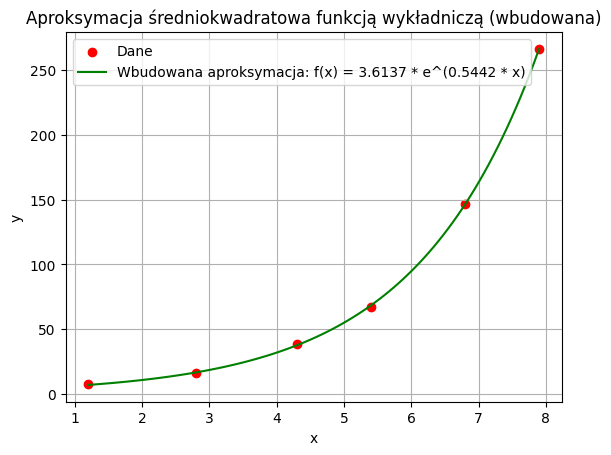

In [31]:
# Aproksymacja za pomocą wbudowanej funkcji curve_fit
def model_function(x, a, b):
    return a * np.exp(b * x)

params, covariance = curve_fit(model_function, x_data, y_data)
a_curve, b_curve = params

# Obliczamy wartości aproksymowane (wbudowana funkcja)
y_curve_approx = model_function(x_data, a_curve, b_curve)

# Obliczamy odchylenie standardowe (wbudowana funkcja)
residuals_curve = y_data - y_curve_approx
standard_deviation_curve = np.sqrt(np.sum(residuals_curve**2) / len(x_data))

# Wyświetlenie wyników (wbudowana funkcja)
equation_str_curve = f"f(x) = {a_curve:.4f} * e^({b_curve:.4f} * x)"
print(f"Wyznaczone parametry (wbudowana aproksymacja): a = {a_curve:.4f}, b = {b_curve:.4f}")
print(f"Odchylenie standardowe (wbudowana aproksymacja): {standard_deviation_curve:.4f}")
print(f"Równanie aproksymującej funkcji (wbudowana aproksymacja): {equation_str_curve}")
# Rysowanie wykresu (wbudowana funkcja)
def plot_approximation_curve_fit():
    plt.scatter(x_data, y_data, color='red', label='Dane')
    x_plot = np.linspace(min(x_data), max(x_data), 100)
    y_plot_curve = model_function(x_plot, a_curve, b_curve)
    plt.plot(x_plot, y_plot_curve, color='green', label=f'Wbudowana aproksymacja: {equation_str_curve}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Aproksymacja średniokwadratowa funkcją wykładniczą (wbudowana)')
    plt.grid()
    plt.show()

plot_approximation_curve_fit()


# Zadanie 5

Wielomian trzeciego stopnia: µk(x) = 1.7957 * x^0 + -0.0393 * x^1 + 0.0003 * x^2 + -0.0000 * x^3
Dla T = 10°C, µk = 1.4345 (10^-3 m^2/s)
Dla T = 30°C, µk = 0.8889 (10^-3 m^2/s)
Dla T = 60°C, µk = 0.4366 (10^-3 m^2/s)
Dla T = 90°C, µk = 0.3016 (10^-3 m^2/s)


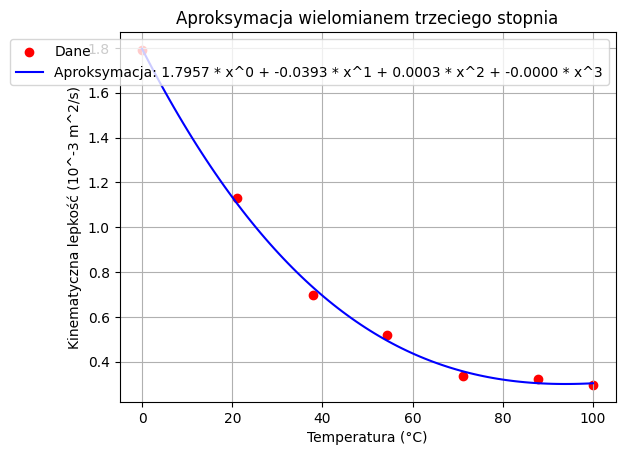

In [34]:
# Definiujemy dane
t_data = np.array([0, 21.1, 37.8, 54.4, 71.1, 87.8, 100])
mu_k_data = np.array([1.79, 1.13, 0.696, 0.519, 0.338, 0.321, 0.296])

# Stopień wielomianu
m = 3

# Liczba punktów danych
n = len(t_data)

# Tworzymy macierz układu normalnego i wektor prawej strony
G = np.zeros((m + 1, m + 1))
R = np.zeros(m + 1)

# Wypełniamy macierz G i wektor R zgodnie z układem normalnym
for k in range(m + 1):
    for i in range(m + 1):
        G[k, i] = np.sum(t_data**(i + k))
    R[k] = np.sum(mu_k_data * t_data**k)

# Rozwiązujemy układ równań normalnych, aby znaleźć współczynniki wielomianu
coefficients = np.linalg.solve(G, R)

# Definiujemy aproksymowany wielomian trzeciego stopnia
def cubic_polynomial(x):
    return sum(coefficients[i] * x**i for i in range(len(coefficients)))

# Wyznaczamy wartości µk dla T = 10, 30, 60, 90
t_values = [10, 30, 60, 90]
mu_k_values = [cubic_polynomial(t) for t in t_values]

# Wyświetlenie wyników
equation_str = " + ".join([f"{coefficients[i]:.4f} * x^{i}" for i in range(len(coefficients))])
print(f"Wielomian trzeciego stopnia: µk(x) = {equation_str}")
for t, mu_k in zip(t_values, mu_k_values):
    print(f"Dla T = {t}°C, µk = {mu_k:.4f} (10^-3 m^2/s)")

# Rysowanie wykresu
def plot_approximation():
    plt.scatter(t_data, mu_k_data, color='red', label='Dane')
    t_plot = np.linspace(min(t_data), max(t_data), 100)
    mu_k_plot = cubic_polynomial(t_plot)
    plt.plot(t_plot, mu_k_plot, color='blue', label=f'Aproksymacja: {equation_str}')
    plt.xlabel('Temperatura (°C)')
    plt.ylabel('Kinematyczna lepkość (10^-3 m^2/s)')
    plt.legend()
    plt.title('Aproksymacja wielomianem trzeciego stopnia')
    plt.grid()
    plt.show()

plot_approximation()


Za pomocą funkcji wbudowanej

Wielomian trzeciego stopnia (wbudowana funkcja): µk(x) = -0.0000 * x^3 + 0.0003 * x^2 + -0.0393 * x^1 + 1.7957 * x^0
Dla T = 10°C, µk = 1.4345 (10^-3 m^2/s)
Dla T = 30°C, µk = 0.8889 (10^-3 m^2/s)
Dla T = 60°C, µk = 0.4366 (10^-3 m^2/s)
Dla T = 90°C, µk = 0.3016 (10^-3 m^2/s)


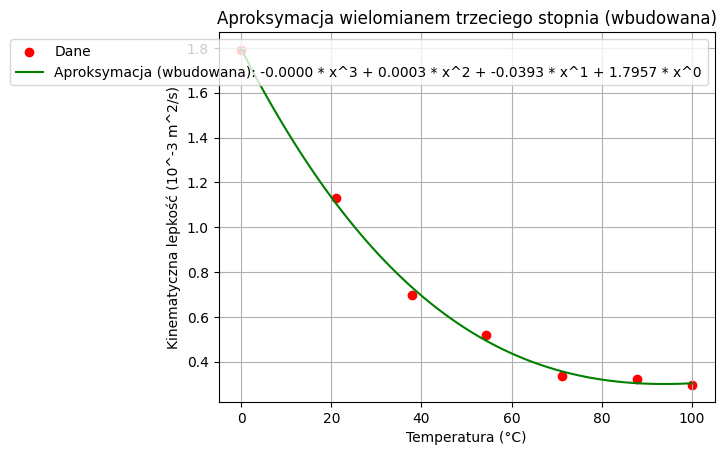

In [36]:

# Używamy funkcji polyfit z numpy, aby dopasować wielomian trzeciego stopnia
coefficients_builtin = np.polyfit(t_data, mu_k_data, 3)

# Definiujemy aproksymowany wielomian trzeciego stopnia przy użyciu wbudowanych współczynników
def cubic_polynomial_builtin(x):
    return np.polyval(coefficients_builtin, x)

# Wyznaczamy wartości µk dla T = 10, 30, 60, 90
t_values = [10, 30, 60, 90]
mu_k_values_builtin = [cubic_polynomial_builtin(t) for t in t_values]

# Wyświetlenie wyników
equation_str_builtin = " + ".join([f"{coeff:.4f} * x^{len(coefficients_builtin) - i - 1}" for i, coeff in enumerate(coefficients_builtin)])
print(f"Wielomian trzeciego stopnia (wbudowana funkcja): µk(x) = {equation_str_builtin}")
for t, mu_k in zip(t_values, mu_k_values_builtin):
    print(f"Dla T = {t}°C, µk = {mu_k:.4f} (10^-3 m^2/s)")

# Rysowanie wykresu (wbudowana aproksymacja)
def plot_approximation_builtin():
    plt.scatter(t_data, mu_k_data, color='red', label='Dane')
    t_plot = np.linspace(min(t_data), max(t_data), 100)
    mu_k_plot_builtin = cubic_polynomial_builtin(t_plot)
    plt.plot(t_plot, mu_k_plot_builtin, color='green', label=f'Aproksymacja (wbudowana): {equation_str_builtin}')
    plt.xlabel('Temperatura (°C)')
    plt.ylabel('Kinematyczna lepkość (10^-3 m^2/s)')
    plt.legend()
    plt.title('Aproksymacja wielomianem trzeciego stopnia (wbudowana)')
    plt.grid()
    plt.show()

plot_approximation_builtin()

# Zadanie 6

Wielomian liniowy: y(x) = -6.1899 * x^0 + 9.4385 * x^1
Wielomian kwadratowy: y(x) = 4.4057 * x^0 + -1.0689 * x^1 + 2.1081 * x^2


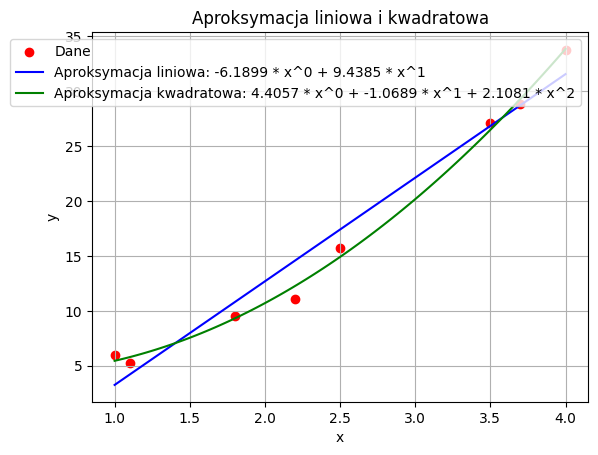

In [38]:
# Definiujemy dane
x_data = np.array([1.0, 2.5, 3.5, 4.0, 1.1, 1.8, 2.2, 3.7])
y_data = np.array([6.008, 15.722, 27.13, 33.772, 5.257, 9.549, 11.098, 28.828])

# Funkcja do obliczania współczynników aproksymacji wielomianowej
def polynomial_fit(x, y, m):
    G = np.zeros((m + 1, m + 1))
    R = np.zeros(m + 1)
    for k in range(m + 1):
        for i in range(m + 1):
            G[k, i] = np.sum(x**(i + k))
        R[k] = np.sum(y * x**k)
    coefficients = np.linalg.solve(G, R)
    return coefficients

# Aproksymacja liniowa (m = 1)
coefficients_linear = polynomial_fit(x_data, y_data, 1)

def linear_function(x):
    return sum(coefficients_linear[i] * x**i for i in range(len(coefficients_linear)))

# Aproksymacja kwadratowa (m = 2)
coefficients_quadratic = polynomial_fit(x_data, y_data, 2)

def quadratic_function(x):
    return sum(coefficients_quadratic[i] * x**i for i in range(len(coefficients_quadratic)))

# Wyznaczanie współczynników i wyświetlanie wyników
linear_equation_str = " + ".join([f"{coefficients_linear[i]:.4f} * x^{i}" for i in range(len(coefficients_linear))])
quadratic_equation_str = " + ".join([f"{coefficients_quadratic[i]:.4f} * x^{i}" for i in range(len(coefficients_quadratic))])

print(f"Wielomian liniowy: y(x) = {linear_equation_str}")
print(f"Wielomian kwadratowy: y(x) = {quadratic_equation_str}")

# Rysowanie wykresów
def plot_approximations():
    plt.scatter(x_data, y_data, color='red', label='Dane')
    x_plot = np.linspace(min(x_data), max(x_data), 100)
    
    # Wykres dla aproksymacji liniowej
    y_plot_linear = linear_function(x_plot)
    plt.plot(x_plot, y_plot_linear, color='blue', label=f'Aproksymacja liniowa: {linear_equation_str}')
    
    # Wykres dla aproksymacji kwadratowej
    y_plot_quadratic = quadratic_function(x_plot)
    plt.plot(x_plot, y_plot_quadratic, color='green', label=f'Aproksymacja kwadratowa: {quadratic_equation_str}')
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Aproksymacja liniowa i kwadratowa')
    plt.grid()
    plt.show()

plot_approximations()

In [40]:
# Obliczanie odchylenia standardowego dla aproksymacji liniowej
y_approx_linear = linear_function_builtin(x_data)
residuals_linear = y_data - y_approx_linear
standard_deviation_linear = np.sqrt(np.sum(residuals_linear**2) / len(x_data))
print(f"Odchylenie standardowe dla aproksymacji liniowej: {standard_deviation_linear:.4f}")

# Obliczanie odchylenia standardowego dla aproksymacji kwadratowej
y_approx_quadratic = quadratic_function_builtin(x_data)
residuals_quadratic = y_data - y_approx_quadratic
standard_deviation_quadratic = np.sqrt(np.sum(residuals_quadratic**2) / len(x_data))
print(f"Odchylenie standardowe dla aproksymacji kwadratowej: {standard_deviation_quadratic:.4f}")

Odchylenie standardowe dla aproksymacji liniowej: 1.9430
Odchylenie standardowe dla aproksymacji kwadratowej: 0.6427
